In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [4]:
df = pd.read_csv('canada_per_capita_income.csv')
df.head(3)

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484


In [6]:
X = df[['year']]
y = df['per capita income (US$)']

The independent variable (X) is the year, and the dependent variable (y) is the per capita income. The goal is to predict income based on the year.

In [7]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

Polynomial features were created to transform the linear relationship into a non-linear one by adding a squared term (year²). This allows the model to capture curved trends in the data.

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

A Linear Regression model was trained on the transformed polynomial features. This enables the model to learn a non-linear relationship between year and income.

In [9]:
y_pred = model.predict(X_poly)

The trained model was used to predict income values based on the polynomial features.

In [11]:
from sklearn.metrics import r2_score

r2 = r2_score(y, y_pred)
print("Polynomial R²:", r2)

Polynomial R²: 0.9290565008926308


The R² score was calculated to evaluate model performance. A higher R² indicates a better fit.

The polynomial model achieved a higher R² score = 0.9290565008926308 >
 linear_reg = 0.890916917957032

indicating improved accuracy.

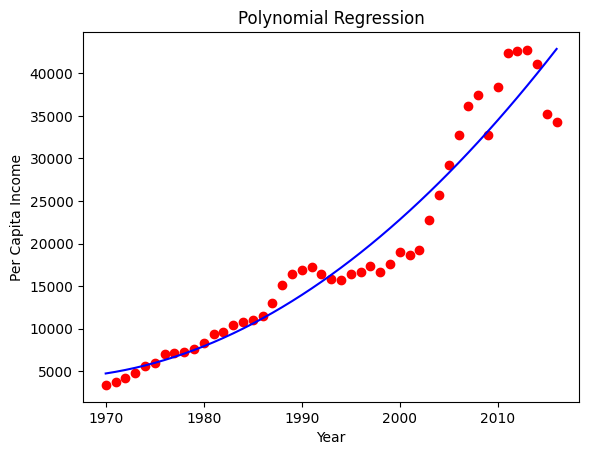

In [12]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color='red')       # actual data
plt.plot(X, y_pred, color='blue')    # polynomial curve
plt.xlabel("Year")
plt.ylabel("Per Capita Income")
plt.title("Polynomial Regression")
plt.show()

A scatter plot of actual data and a curve representing the polynomial regression model were plotted to visually assess the model fit.

Prediction of 2025 and 2026

In [13]:
model.predict(poly.transform([[2025]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([57306.85544173])

In [14]:
model.predict(poly.transform([[2026]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([59054.28401475])

In [15]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse_poly = mean_squared_error(y, y_pred)
rmse_poly = np.sqrt(mse_poly)

print("Polynomial MSE:", mse_poly)
print("Polynomial RMSE:", rmse_poly)

Polynomial MSE: 10056378.99353856
Polynomial RMSE: 3171.17943256741


The Mean Squared Error (MSE) and Root Mean Squared Error (RMSE) were calculated to measure prediction error. The polynomial model showed a lower RMSE compared to linear regression, indicating better accuracy.

The linear regression model showed a good fit with an R² score of 0.89. However, the data exhibited a non-linear trend. By applying polynomial regression, the model performance improved significantly, achieving a higher R² score and lower RMSE. This demonstrates that polynomial regression is more suitable for capturing the growth pattern of per capita income over time.

Polynomial regression improved the model performance significantly compared to linear regression by capturing the non-linear growth pattern in income.